# Laboratorio 7
**CC3066 Data Science - Semestre II 2026 - Universidad del Valle de Guatemala**

##  Configuración del entorno

In [1]:
import os, glob, sys
from pathlib import Path

# Java 17 para Spark 3.5: si JAVA_HOME no está definido (p. ej. fuera del docker del curso),
# se usa el JDK portable del proyecto en .env/
if not os.environ.get("JAVA_HOME"):
    jdk = sorted(glob.glob(".env/jdk-*/Contents/Home")) + sorted(glob.glob(".env/jdk-*"))
    if jdk:
        os.environ["JAVA_HOME"] = str(Path(jdk[0]).resolve())
os.environ.setdefault("PYSPARK_PYTHON", sys.executable)
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))

JAVA_HOME: /Users/a87009/Documents/Año 4 Semestre 2/Data Science/Laboratorio 7/.env/jdk-17.0.20.1+1/Contents/Home


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import openpyxl

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

spark = (SparkSession.builder
         .appName("Lab7-ENEIC")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.execution.arrow.pyspark.enabled", "true")
         .config("spark.sql.session.timeZone", "America/Guatemala")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid", context="notebook")
SEED = 42
MAX_MUESTRA = 5000  # tamaño máximo de muestras que se llevan a pandas para graficar

Spark 3.5.1


### Archivos y período de procedencia

In [3]:
DATA = Path("data")
RAW, DICC, PQ = DATA / "raw", DATA / "diccionarios", DATA / "parquet"

ARCHIVOS = pd.DataFrame([
    # archivo local,            período, año, trim, uso,                       diccionario
    ("personas_2025T1.xlsx", "2025T1", 2025, 1, "Desarrollo y entrenamiento", "dicc_2025T1.xlsx"),
    ("personas_2025T2.xlsx", "2025T2", 2025, 2, "Desarrollo y entrenamiento", "dicc_2025T2.xlsx"),
    ("personas_2025T3.xlsx", "2025T3", 2025, 3, "Desarrollo y entrenamiento", "dicc_2025T3.xlsx"),
    ("personas_2025T4.xlsx", "2025T4", 2025, 4, "Validación y entrenamiento final", "dicc_2025T4.xlsx"),
    ("personas_2026T1.xlsx", "2026T1", 2026, 1, "Prueba final", "dicc_2026T1.xlsx"),
], columns=["archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario", "uso", "diccionario"])

# Fuente: https://www.ine.gob.gt/encuesta-nacional-de-empleo-e-ingresos/
FUENTE_INE = {
    "personas_2025T1.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas_ENEIC_T1_2025.xlsx",
    "personas_2025T2.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/01/Personas-ENEIC-T2-2025.xlsx",
    "personas_2025T3.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/05/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "personas_2025T4.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/06/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "personas_2026T1.xlsx": "https://www.ine.gob.gt/wp-content/uploads/2026/09/Base-de-datos-Personas-ENEIC-I-2026.xlsx",
}
ARCHIVOS

,archivo_origen,periodo_archivo,anio_archivo,trimestre_calendario,uso,diccionario
0,personas_2025T1.xlsx,2025T1,2025,1,Desarrollo y entrenamiento,dicc_2025T1.xlsx
1,personas_2025T2.xlsx,2025T2,2025,2,Desarrollo y entrenamiento,dicc_2025T2.xlsx
2,personas_2025T3.xlsx,2025T3,2025,3,Desarrollo y entrenamiento,dicc_2025T3.xlsx
3,personas_2025T4.xlsx,2025T4,2025,4,Validación y entrenamiento final,dicc_2025T4.xlsx
4,personas_2026T1.xlsx,2026T1,2026,1,Prueba final,dicc_2026T1.xlsx


In [4]:
RENOMBRE = {
    "P05D01": "salario_mensual", "P02A03": "edad", "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses", "P05H01A": "horas_semanales", "P03A03A": "nivel_educativo_cod",
    "P05C16": "categoria_ocupacional_cod", "DOMINIO": "dominio_cod", "OCUPADOS": "ocupado",
    "NUM_HOGAR": "NUM_HOGAR", "NUM_PERSONA": "NUM_PERSONA", "FACTOR": "FACTOR",
    "ANIO": "ANIO", "TRIMESTRE": "TRIMESTRE",
}
COLS_ORIG = list(RENOMBRE)

# Tipos explícitos del conjunto armonizado
TIPOS = {
    "salario_mensual": "double", "edad": "double", "antiguedad_anios": "double",
    "antiguedad_meses": "double", "horas_semanales": "double", "nivel_educativo_cod": "int",
    "categoria_ocupacional_cod": "int", "dominio_cod": "int", "ocupado": "int",
    "NUM_HOGAR": "long", "NUM_PERSONA": "int", "FACTOR": "double", "ANIO": "int", "TRIMESTRE": "int",
}

### Estructura de los archivos originales

In [5]:
def encabezado(ruta):
    wb = openpyxl.load_workbook(ruta, read_only=True)
    ws = wb[wb.sheetnames[0]]
    hdr = [str(h).strip().upper() if h is not None else None for h in next(ws.iter_rows(max_row=1, values_only=True))]
    wb.close()
    return hdr

HEADERS = {r.periodo_archivo: encabezado(RAW / r.archivo_origen) for r in ARCHIVOS.itertuples()}
posiciones = pd.DataFrame({p: {c: (h.index(c) if c in h else None) for c in COLS_ORIG} for p, h in HEADERS.items()})
posiciones.loc["N° columnas"] = {p: len(h) for p, h in HEADERS.items()}
print("Posición (índice 0) de cada variable requerida en cada archivo:")
posiciones

Posición (índice 0) de cada variable requerida en cada archivo:


,2025T1,2025T2,2025T3,2025T4,2026T1
P05D01,104,104,104,97,104
P02A03,12,12,12,8,12
P05C07A,67,67,67,60,67
P05C07B,68,68,68,61,68
P05H01A,217,217,217,207,217
P03A03A,32,32,32,28,32
P05C16,87,87,87,80,87
DOMINIO,2,2,2,2,2
OCUPADOS,265,265,265,297,265
NUM_HOGAR,3,3,3,3,3


In [6]:
base = HEADERS["2025T1"]
for p, h in HEADERS.items():
    solo_p = [c for c in h if c not in base]
    solo_base = [c for c in base if c not in h]
    print(f"{p}: {len(h)} columnas | nuevas vs 2025T1: {len(solo_p)} | ausentes vs 2025T1: {len(solo_base)} "
          f"| mismo orden que 2025T1: {h == base}")
print("\nEjemplo de columnas nuevas en 2025T4:", [c for c in HEADERS["2025T4"] if c not in base][:15])

2025T1: 270 columnas | nuevas vs 2025T1: 0 | ausentes vs 2025T1: 0 | mismo orden que 2025T1: True
2025T2: 270 columnas | nuevas vs 2025T1: 0 | ausentes vs 2025T1: 0 | mismo orden que 2025T1: True
2025T3: 270 columnas | nuevas vs 2025T1: 0 | ausentes vs 2025T1: 0 | mismo orden que 2025T1: True
2025T4: 302 columnas | nuevas vs 2025T1: 42 | ausentes vs 2025T1: 10 | mismo orden que 2025T1: False
2026T1: 270 columnas | nuevas vs 2025T1: 0 | ausentes vs 2025T1: 0 | mismo orden que 2025T1: True

Ejemplo de columnas nuevas en 2025T4: ['P07A01A', 'P07A01B', 'P07A01C', 'P07A02A', 'P07A02B', 'P07A02C', 'P07A03A', 'P07A03B', 'P07A03C', 'P07A04A', 'P07A04B', 'P07A04C', 'P08A01A', 'P08A01B', 'P08A01C']


### Conversión Excel a Parquet (archivo por archivo)

In [7]:
REPROCESAR = False   # True fuerza volver a leer los Excel
ESQ_TEXTO = T.StructType([T.StructField(c, T.StringType(), True) for c in COLS_ORIG])

def excel_a_parquet(r):
    destino = PQ / "crudo" / r.periodo_archivo
    if destino.exists() and not REPROCESAR:
        return "ya existía"
    pdf = pd.read_excel(RAW / r.archivo_origen, dtype=str, engine="openpyxl",
                        usecols=lambda c: str(c).strip().upper() in RENOMBRE)
    pdf.columns = [str(c).strip().upper() for c in pdf.columns]
    pdf = pdf[COLS_ORIG].astype(object).where(pdf[COLS_ORIG].notna(), None)
    sdf = (spark.createDataFrame(pdf, schema=ESQ_TEXTO)
           .withColumn("archivo_origen", F.lit(r.archivo_origen))
           .withColumn("periodo_archivo", F.lit(r.periodo_archivo))
           .withColumn("anio_archivo", F.lit(r.anio_archivo).cast("int"))
           .withColumn("trimestre_calendario", F.lit(r.trimestre_calendario).cast("int")))
    sdf.write.mode("overwrite").parquet(str(destino))
    n = len(pdf)
    del pdf
    return f"convertido ({n:,} filas)"

for r in ARCHIVOS.itertuples():
    print(r.periodo_archivo, "→", excel_a_parquet(r))

2025T1 → ya existía
2025T2 → ya existía
2025T3 → ya existía
2025T4 → ya existía
2026T1 → ya existía


### Armonización de tipos

In [8]:
def texto_a_num(c):
    s = F.trim(F.col(c))
    return F.when(s == "", None).otherwise(s.cast("double"))

def armonizar(sdf):
    cols = []
    for orig, nuevo in RENOMBRE.items():
        x = texto_a_num(orig)
        if TIPOS[nuevo] in ("int", "long"):
            x = F.when(x == F.floor(x), x).cast(TIPOS[nuevo])
        cols.append(x.alias(nuevo))
    no_conv = [F.sum(F.when(F.col(o).isNotNull() & (F.trim(F.col(o)) != "") & texto_a_num(o).isNull(), 1)
                     .otherwise(0)).alias(RENOMBRE[o]) for o in COLS_ORIG]
    meta = ["archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario"]
    return sdf.select(*meta, *cols), sdf.agg(*no_conv)

crudos = {r.periodo_archivo: spark.read.parquet(str(PQ / "crudo" / r.periodo_archivo)) for r in ARCHIVOS.itertuples()}
armonizados, no_convertibles = {}, []
for p, sdf in crudos.items():
    a, nc = armonizar(sdf)
    armonizados[p] = a
    no_convertibles.append(nc.toPandas().assign(periodo_archivo=p))

print("Valores no nulos que no pudieron convertirse a número (por archivo):")
pd.concat(no_convertibles).set_index("periodo_archivo")

Valores no nulos que no pudieron convertirse a número (por archivo):


,salario_mensual,edad,antiguedad_anios,antiguedad_meses,horas_semanales,nivel_educativo_cod,categoria_ocupacional_cod,dominio_cod,ocupado,NUM_HOGAR,NUM_PERSONA,FACTOR,ANIO,TRIMESTRE
periodo_archivo,,,,,,,,,,,,,,
2025T1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025T2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025T3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2025T4,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2026T1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### Unión con unionByName

In [9]:
from functools import reduce
P2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]
df25_crudo = reduce(lambda a, b: a.unionByName(b), [armonizados[p] for p in P2025]).persist()
df26_crudo = armonizados["2026T1"].persist()
df_todos_crudo = df25_crudo.unionByName(df26_crudo)

df25_crudo.printSchema()
df25_crudo.show(5, truncate=False)

root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)



+--------------------+---------------+------------+--------------------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+---------+-----------+------+----+---------+
|archivo_origen      |periodo_archivo|anio_archivo|trimestre_calendario|salario_mensual|edad|antiguedad_anios|antiguedad_meses|horas_semanales|nivel_educativo_cod|categoria_ocupacional_cod|dominio_cod|ocupado|NUM_HOGAR|NUM_PERSONA|FACTOR|ANIO|TRIMESTRE|
+--------------------+---------------+------------+--------------------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+---------+-----------+------+----+---------+
|personas_2025T1.xlsx|2025T1         |2025        |1                   |19125.0        |51.0|15.0            |0.0             |48.0           |6                  |1                        |1          |1      |6676     |1          |244.0 |

### Validación de códigos contra el diccionario

In [10]:
def valores_diccionario(ruta, variables):
    d = pd.read_excel(ruta, header=None, dtype=str)
    col0 = d[0].astype(str).str.strip()
    inicio = d.index[col0.str.lower() == "valores de variable"][0]
    salida, actual = {}, None
    for _, fila in d.loc[inicio + 1:].iterrows():
        if pd.notna(fila[0]) and str(fila[0]).strip():
            actual = str(fila[0]).strip().upper()
        if actual in variables and pd.notna(fila[1]):
            try:
                cod = int(float(fila[1]))
            except ValueError:
                continue
            salida.setdefault(actual, {})[cod] = str(fila[2]).strip().rstrip("?").strip()
    return salida

VARS_CAT = ["P03A03A", "P05C16", "DOMINIO", "OCUPADOS"]
DICCIONARIOS = {r.periodo_archivo: valores_diccionario(DICC / r.diccionario, VARS_CAT) for r in ARCHIVOS.itertuples()}

comparacion = pd.DataFrame({p: {v: sorted(d[v]) for v in VARS_CAT} for p, d in DICCIONARIOS.items()})
print("¿Códigos idénticos en los 5 diccionarios?",
      {v: len({tuple(DICCIONARIOS[p][v].items()) for p in DICCIONARIOS}) == 1 for v in VARS_CAT})
comparacion

¿Códigos idénticos en los 5 diccionarios? {'P03A03A': True, 'P05C16': True, 'DOMINIO': True, 'OCUPADOS': True}


,2025T1,2025T2,2025T3,2025T4,2026T1
P03A03A,"[0, 1, 2, 3, 4, 5, 6, 7]","[0, 1, 2, 3, 4, 5, 6, 7]","[0, 1, 2, 3, 4, 5, 6, 7]","[0, 1, 2, 3, 4, 5, 6, 7]","[0, 1, 2, 3, 4, 5, 6, 7]"
P05C16,"[1, 2, 3, 4, 5, 6, 7, 8, 9]","[1, 2, 3, 4, 5, 6, 7, 8, 9]","[1, 2, 3, 4, 5, 6, 7, 8, 9]","[1, 2, 3, 4, 5, 6, 7, 8, 9]","[1, 2, 3, 4, 5, 6, 7, 8, 9]"
DOMINIO,"[1, 2, 3]","[1, 2, 3]","[1, 2, 3]","[1, 2, 3]","[1, 2, 3]"
OCUPADOS,[1],[1],[1],[1],[1]


In [11]:
D = DICCIONARIOS["2025T1"]
ETIQ_EDU = {k: v.capitalize() for k, v in D["P03A03A"].items()}
ETIQ_CAT = {k: v for k, v in D["P05C16"].items()}
ETIQ_DOM = {k: v for k, v in D["DOMINIO"].items()}
print(ETIQ_EDU, ETIQ_CAT, ETIQ_DOM, sep="\n")

# Códigos presentes en los datos que NO están en el diccionario (antes de filtrar)
for col, etq in [("nivel_educativo_cod", ETIQ_EDU), ("categoria_ocupacional_cod", ETIQ_CAT), ("dominio_cod", ETIQ_DOM)]:
    obs = (df_todos_crudo.groupBy(col).count().orderBy(col).toPandas())
    fuera = obs[obs[col].notna() & ~obs[col].isin(list(etq))]
    print(f"{col}: códigos observados {obs[col].dropna().astype(int).tolist()} | no reconocidos: {fuera[col].tolist()}")

{0: 'Ninguno', 1: 'Preprimaria', 2: 'Primaria', 3: 'Básico', 4: 'Diversificado', 5: 'Superior', 6: 'Maestría', 7: 'Doctorado'}
{1: 'Empleado de gobierno', 2: 'Empleado de empresa privada', 3: 'Empleado jornalero o peón', 4: 'Del servicio doméstico', 5: 'Trabajador por cuenta propia NO agrícola', 6: 'Patrón empleador (a) socio (a) NO agrícola', 7: 'Trabajador por cuenta propia agrícola', 8: 'Patrón empleador (a) socio (a) agrícola', 9: 'Trabajador No remunerado'}
{1: 'Urbano Metropolitano', 2: 'Resto Urbano', 3: 'Rural Nacional'}


nivel_educativo_cod: códigos observados [0, 1, 2, 3, 4, 5, 6, 7] | no reconocidos: []


categoria_ocupacional_cod: códigos observados [1, 2, 3, 4, 5, 6, 7, 8, 9] | no reconocidos: []


dominio_cod: códigos observados [1, 2, 3] | no reconocidos: []


### Faltantes por variable **antes** de aplicar filtros

In [12]:
VARS_ANALISIS = list(RENOMBRE.values())

def tabla_faltantes(sdf, por="periodo_archivo"):
    agg = sdf.groupBy(por).agg(F.count(F.lit(1)).alias("n"),
                               *[F.sum(F.col(c).isNull().cast("int")).alias(c) for c in VARS_ANALISIS]).toPandas()
    return agg.set_index(por).sort_index()

falt = tabla_faltantes(df_todos_crudo)
total = falt.sum()
resumen_falt = pd.DataFrame({"faltantes_total": total[VARS_ANALISIS].astype(int),
                             "pct_total": (100 * total[VARS_ANALISIS] / total["n"]).round(2)})
pct_por_archivo = (100 * falt[VARS_ANALISIS].div(falt["n"], axis=0)).round(2).T
pct_por_archivo.columns = [f"% {c}" for c in pct_por_archivo.columns]
print(f"Total de registros (5 archivos): {int(total['n']):,}")
resumen_falt.join(pct_por_archivo)

Total de registros (5 archivos): 253,519


,faltantes_total,pct_total,% 2025T1,% 2025T2,% 2025T3,% 2025T4,% 2026T1
salario_mensual,187236,73.85,73.99,73.63,73.93,74.33,73.40
edad,0,0.00,0.00,0.00,0.00,0.00,0.00
antiguedad_anios,143563,56.63,56.83,56.33,56.63,56.96,56.40
antiguedad_meses,143563,56.63,56.83,56.33,56.63,56.96,56.40
horas_semanales,143563,56.63,56.83,56.33,56.63,56.96,56.40
nivel_educativo_cod,32355,12.76,13.43,13.05,12.69,12.55,12.06
categoria_ocupacional_cod,143563,56.63,56.83,56.33,56.63,56.96,56.40
dominio_cod,0,0.00,0.00,0.00,0.00,0.00,0.00
ocupado,143563,56.63,56.83,56.33,56.63,56.96,56.40
NUM_HOGAR,0,0.00,0.00,0.00,0.00,0.00,0.00


In [13]:
# Faltantes dentro del universo donde la pregunta SÍ corresponde:
# ocupados de 15+ años que son asalariados (P05C16 1-4)
universo = df_todos_crudo.filter((F.col("edad") >= 15) & (F.col("ocupado") == 1) &
                                 F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4))
f_u = tabla_faltantes(universo).sum()
pd.DataFrame({"faltantes": f_u[VARS_ANALISIS].astype(int),
              "pct": (100 * f_u[VARS_ANALISIS] / f_u["n"]).round(2)}).T.assign(n_universo=int(f_u["n"]))

,salario_mensual,edad,antiguedad_anios,antiguedad_meses,horas_semanales,nivel_educativo_cod,categoria_ocupacional_cod,dominio_cod,ocupado,NUM_HOGAR,NUM_PERSONA,FACTOR,ANIO,TRIMESTRE,n_universo
faltantes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66283
pct,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66283


### Filtros de la población analítica 

In [14]:
def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(F.col(c)) & (F.abs(F.col(c)) != float("inf"))

ANT = F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12

FILTROS = [
    ("1. Edad finita y ≥ 15",                     finito("edad") & (F.col("edad") >= 15)),
    ("2. Ocupado (OCUPADOS = 1)",                 F.col("ocupado") == 1),
    ("3. Asalariado (P05C16 ∈ {1,2,3,4})",        F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)),
    ("4. Salario numérico, finito y > 0",         finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5. Antigüedad registrada (años y meses)",   finito("antiguedad_anios") & finito("antiguedad_meses")),
    ("6. Meses entero entre 0 y 11",              (F.col("antiguedad_meses") == F.floor("antiguedad_meses")) &
                                                  F.col("antiguedad_meses").between(0, 11)),
    ("7. Antigüedad en años no negativa",         (F.col("antiguedad_anios") >= 0) & (ANT >= 0)),
    ("8. Antigüedad ≤ edad",                      ANT <= F.col("edad")),
    ("9. Horas habituales registradas",           finito("horas_semanales")),
    ("10. Horas habituales en (0, 168]",          (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]

def aplicar_filtros(sdf):
    conteos = [sdf.groupBy("periodo_archivo").count().withColumnRenamed("count", "0. Registros originales")]
    actual = sdf
    for nombre, cond in FILTROS:
        actual = actual.filter(F.coalesce(cond, F.lit(False)))
        conteos.append(actual.groupBy("periodo_archivo").count().withColumnRenamed("count", nombre))
    tabla = reduce(lambda a, b: a.join(b, "periodo_archivo", "left"), conteos).toPandas()
    tabla = tabla.set_index("periodo_archivo").sort_index().fillna(0).astype(int).T
    return actual, tabla

filtrado_todos, conteo_filtros = aplicar_filtros(df_todos_crudo)
conteo_filtros["Total 2025"] = conteo_filtros[P2025].sum(axis=1)
excluidos = (conteo_filtros.shift(1) - conteo_filtros).iloc[1:].astype(int)
excluidos.index = ["Excluidos en " + i for i in excluidos.index]

print("Registros que QUEDAN después de cada paso:")
display(conteo_filtros)
print("Registros EXCLUIDOS en cada paso:")
display(excluidos)

Registros que QUEDAN después de cada paso:


periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1,Total 2025
0. Registros originales,51588,51167,51583,49338,49843,203676
1. Edad finita y ≥ 15,35335,35285,35816,34354,35040,140790
2. Ocupado (OCUPADOS = 1),22273,22343,22373,21233,21734,88222
"3. Asalariado (P05C16 ∈ {1,2,3,4})",13419,13492,13450,12664,13258,53025
"4. Salario numérico, finito y > 0",13419,13492,13450,12664,13258,53025
5. Antigüedad registrada (años y meses),13419,13492,13450,12664,13258,53025
6. Meses entero entre 0 y 11,13419,13492,13450,12664,13258,53025
7. Antigüedad en años no negativa,13419,13492,13450,12664,13258,53025
8. Antigüedad ≤ edad,13419,13492,13450,12664,13258,53025
9. Horas habituales registradas,13419,13492,13450,12664,13258,53025


Registros EXCLUIDOS en cada paso:


periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1,Total 2025
Excluidos en 1. Edad finita y ≥ 15,16253,15882,15767,14984,14803,62886
Excluidos en 2. Ocupado (OCUPADOS = 1),13062,12942,13443,13121,13306,52568
"Excluidos en 3. Asalariado (P05C16 ∈ {1,2,3,4})",8854,8851,8923,8569,8476,35197
"Excluidos en 4. Salario numérico, finito y > 0",0,0,0,0,0,0
Excluidos en 5. Antigüedad registrada (años y meses),0,0,0,0,0,0
Excluidos en 6. Meses entero entre 0 y 11,0,0,0,0,0,0
Excluidos en 7. Antigüedad en años no negativa,0,0,0,0,0,0
Excluidos en 8. Antigüedad ≤ edad,0,0,0,0,0,0
Excluidos en 9. Horas habituales registradas,0,0,0,0,0,0
"Excluidos en 10. Horas habituales en (0, 168]",0,0,0,0,0,0


In [15]:
antes_despues = pd.DataFrame({
    "antes_filtros": conteo_filtros.iloc[0],
    "despues_filtros": conteo_filtros.iloc[-1],
})
antes_despues["pct_retenido"] = (100 * antes_despues.despues_filtros / antes_despues.antes_filtros).round(2)
antes_despues

,antes_filtros,despues_filtros,pct_retenido
periodo_archivo,,,
2025T1,51588,13419,26.01
2025T2,51167,13492,26.37
2025T3,51583,13450,26.07
2025T4,49338,12664,25.67
2026T1,49843,13258,26.60
Total 2025,203676,53025,26.03


### Variables derivadas y etiquetas categóricas

In [16]:
def mapa(d):
    return F.create_map(*[x for k, v in d.items() for x in (F.lit(k), F.lit(v))])

def etiquetar(sdf):
    return (sdf
            .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)
            .withColumn("nivel_educativo", F.coalesce(mapa(ETIQ_EDU)[F.col("nivel_educativo_cod")], F.lit("DESCONOCIDO")))
            .withColumn("categoria_ocupacional", F.coalesce(mapa(ETIQ_CAT)[F.col("categoria_ocupacional_cod")], F.lit("DESCONOCIDO")))
            .withColumn("dominio", F.coalesce(mapa(ETIQ_DOM)[F.col("dominio_cod")], F.lit("DESCONOCIDO"))))

COLS_FINALES = ["archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario", "ANIO", "TRIMESTRE",
                "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ocupado",
                "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad", "horas_semanales",
                "nivel_educativo_cod", "nivel_educativo", "categoria_ocupacional_cod", "categoria_ocupacional",
                "dominio_cod", "dominio"]

prep_todos = etiquetar(filtrado_todos).select(*COLS_FINALES)
df25 = prep_todos.filter(F.col("anio_archivo") == 2025).persist()
df26 = prep_todos.filter(F.col("anio_archivo") == 2026).persist()
print(f"2025 preparado: {df25.count():,} registros | 2026 preparado: {df26.count():,} registros")

for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(c, "→ DESCONOCIDO en 2025:", df25.filter(F.col(c) == "DESCONOCIDO").count(),
          "| en 2026:", df26.filter(F.col(c) == "DESCONOCIDO").count())

2025 preparado: 53,025 registros | 2026 preparado: 13,258 registros


nivel_educativo → DESCONOCIDO en 2025: 0 | en 2026: 0


categoria_ocupacional → DESCONOCIDO en 2025: 0 | en 2026: 0


dominio → DESCONOCIDO en 2025: 0 | en 2026: 0


### Columna TRIMESTRE original vs período del archivo

In [17]:
(df_todos_crudo.groupBy("periodo_archivo", "ANIO", "TRIMESTRE").count()
 .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,periodo_archivo,ANIO,TRIMESTRE,count
0,2025T1,2025,2,51588
1,2025T2,2025,2,175
2,2025T2,2025,3,50992
3,2025T3,2025,4,51583
4,2025T4,2025,5,49338
5,2026T1,2026,6,49843


### Verificación de unicidad de periodo_archivo + NUM_HOGAR + NUM_PERSONA

In [18]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

def revisar_unicidad(sdf, nombre):
    nulos = sdf.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
    rep = sdf.groupBy(CLAVE).agg(F.count(F.lit(1)).alias("veces"),
                                 F.countDistinct(F.to_json(F.struct(*sdf.columns))).alias("versiones"))
    rep = rep.filter("veces > 1")
    res = rep.agg(F.count(F.lit(1)).alias("claves_repetidas"),
                  F.coalesce(F.sum("veces"), F.lit(0)).alias("filas_involucradas"),
                  F.coalesce(F.sum((F.col("versiones") == 1).cast("int")), F.lit(0)).alias("repeticiones_exactas"),
                  F.coalesce(F.sum((F.col("versiones") > 1).cast("int")), F.lit(0)).alias("claves_en_conflicto")).toPandas()
    res.insert(0, "conjunto", nombre)
    res.insert(1, "filas", sdf.count())
    res.insert(2, "claves_nulas", nulos)
    return res, rep

u1, rep1 = revisar_unicidad(df_todos_crudo, "Bases completas (5 archivos)")
u2, _ = revisar_unicidad(df25, "2025 preparado")
u3, _ = revisar_unicidad(df26, "2026 preparado")
pd.concat([u1, u2, u3], ignore_index=True)

,conjunto,filas,claves_nulas,claves_repetidas,filas_involucradas,repeticiones_exactas,claves_en_conflicto
0,Bases completas (5 archivos),253519,0,0,0,0,0
1,2025 preparado,53025,0,0,0,0,0
2,2026 preparado,13258,0,0,0,0,0


In [ ]:
if rep1.count() > 0:
    df_todos_crudo.join(rep1.select(CLAVE), CLAVE).orderBy(*CLAVE).show(20, truncate=False)
else:
    print("No hay claves repetidas: cada (periodo_archivo, NUM_HOGAR, NUM_PERSONA) identifica una sola fila.")

No hay claves repetidas: cada (periodo_archivo, NUM_HOGAR, NUM_PERSONA) identifica una sola fila.


### Personas observadas en más de un período (diseño longitudinal)

In [20]:
apar = (df25.groupBy("NUM_HOGAR", "NUM_PERSONA")
        .agg(F.countDistinct("periodo_archivo").alias("periodos"),
             (F.max("edad") - F.min("edad")).alias("rango_edad")))
dist_apar = apar.groupBy("periodos").count().orderBy("periodos").toPandas()
dist_apar["pct"] = (100 * dist_apar["count"] / dist_apar["count"].sum()).round(2)
print("Personas distintas (hogar+persona) en 2025 preparado:", int(dist_apar["count"].sum()),
      "| filas:", df25.count())
display(dist_apar)
print("Entre quienes aparecen en ≥2 períodos, % con diferencia de edad ≤ 1 año:",
      round(100 * apar.filter("periodos > 1").select(F.avg((F.col("rango_edad") <= 1).cast("int"))).first()[0], 2))

Personas distintas (hogar+persona) en 2025 preparado: 26709 | filas: 53025


,periodos,count,pct
0,1,11303,42.32
1,2,7831,29.32
2,3,4240,15.87
3,4,3335,12.49


Entre quienes aparecen en ≥2 períodos, % con diferencia de edad ≤ 1 año: 99.58


### Guardado de los conjuntos preparados en Parquet

In [21]:
df25.write.mode("overwrite").parquet(str(PQ / "eneic_2025_preparado"))
df26.write.mode("overwrite").parquet(str(PQ / "eneic_2026_preparado"))
df25 = spark.read.parquet(str(PQ / "eneic_2025_preparado")).persist()
df26 = spark.read.parquet(str(PQ / "eneic_2026_preparado"))
print("Guardado:", PQ / "eneic_2025_preparado", f"({df25.count():,})", "|", PQ / "eneic_2026_preparado", f"({df26.count():,})")
df25.printSchema()
df25.show(5, truncate=False)

Guardado: data/parquet/eneic_2025_preparado (53,025) | data/parquet/eneic_2026_preparado (13,258)
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- categoria_ocupacional: string (nulla

### Interpretación:

Procedencia y periodo
Los cinco archivos suman 253,519 filas, igual que en el enunciado. La columna TRIMESTRE no indica el trimestre real, porque va de 2 a 6 y el archivo II-2025 tiene 175 registros con valor 2. Por eso el periodo se tomó del archivo de origen de cada registro.

Tipos de datos
El archivo II-2025 trae los códigos como texto y los demás como números. Todos se convirtieron con la misma regla sin errores. Los códigos coinciden con los diccionarios, así que ningún registro quedó como DESCONOCIDO.

Datos faltantes
Muchas variables tienen faltantes (el salario falta en el 73.9% de las filas y la antigüedad en el 56.6%), porque esas preguntas no se les hacen a las personas que no trabajan. Entre las personas asalariadas de 15 años o más no falta ningún dato.

Filtros
Casi todos los registros se excluyeron por ser menores de 15 años, no estar ocupados o no ser asalariados. Los demás filtros no excluyeron ningún registro. Quedaron 53,025 registros de 2025 y 13,258 de 2026, alrededor del 26% de cada archivo.

Registros únicos
No hay registros repetidos para un mismo periodo, hogar y persona.

Personas en varios periodos
Las filas de 2025 corresponden a 26,709 personas distintas, y más de la mitad aparece en dos o más trimestres. Su edad cambia como máximo un año entre trimestres, lo que confirma que son las mismas personas.

### Respuestas

¿Por qué IV de 2025 no puede apilarse por posición con los otros archivos?
Porque tiene 302 columnas en lugar de 270, así que las variables quedan en otras posiciones. Por ejemplo, el salario está en la columna 97 y no en la 104. Si se apila por posición, se mezclan variables sin que aparezca ningún error. Por eso se unió por nombre de columna con unionByName.

¿Qué diferencia hay entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?
En el primer caso la pregunta no se le hizo a la persona; por ejemplo, no se pregunta el salario a quien no trabaja. No es un error y no se debe rellenar. En el segundo caso la pregunta sí aplicaba, pero no se obtuvo la respuesta. Eso sí es información perdida. En nuestra población analítica no hay respuestas sin registrar.

¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado?
Porque la encuesta sigue a las mismas personas en varios trimestres y cada fila es una observación distinta: el salario, las horas o el empleo pueden cambiar de un trimestre a otro. Eliminarlas haría perder cerca de la mitad de los datos.

¿Por qué el número de registros filtrados no representa a todos los trabajadores del país?
Porque es una muestra, y cada registro representa a muchas personas. Además, solo incluye asalariados de 15 años o más con salario, así que quedan fuera los trabajadores por cuenta propia, los patronos y los no remunerados. También hay personas repetidas: las 53,025 filas son unas 26,700 personas distintas.

Uso de FACTOR
FACTOR indica cuántas personas del país representa cada registro. Serviría para hacer estimaciones de todo el país, como el total de asalariados o el salario promedio nacional. En este laboratorio no se usa, porque los resultados son no ponderados.

## Estadística descriptiva y preguntas de exploración

In [22]:
NUMERICAS = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def descriptivas(sdf, cols):
    filas = []
    for c in cols:
        r = sdf.agg(F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_est"),
                    F.min(c).alias("min"), F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias("p"),
                    F.max(c).alias("max"), F.skewness(c).alias("asimetria")).first()
        filas.append({"variable": c, "n": r.n, "media": r.media, "mediana": r.p[1], "desv_est": r.desv_est,
                      "min": r["min"], "p25": r.p[0], "p75": r.p[2], "p95": r.p[3], "max": r["max"],
                      "asimetria": r.asimetria})
    return pd.DataFrame(filas).set_index("variable")

desc25 = descriptivas(df25, NUMERICAS)
desc25.round(2)

,n,media,mediana,desv_est,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
salario_mensual,53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0,6.00
edad,53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0,0.74
antiguedad,53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0,2.40
horas_semanales,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0,0.59


### Distribución de registros por categoría ocupacional, nivel educativo y dominio

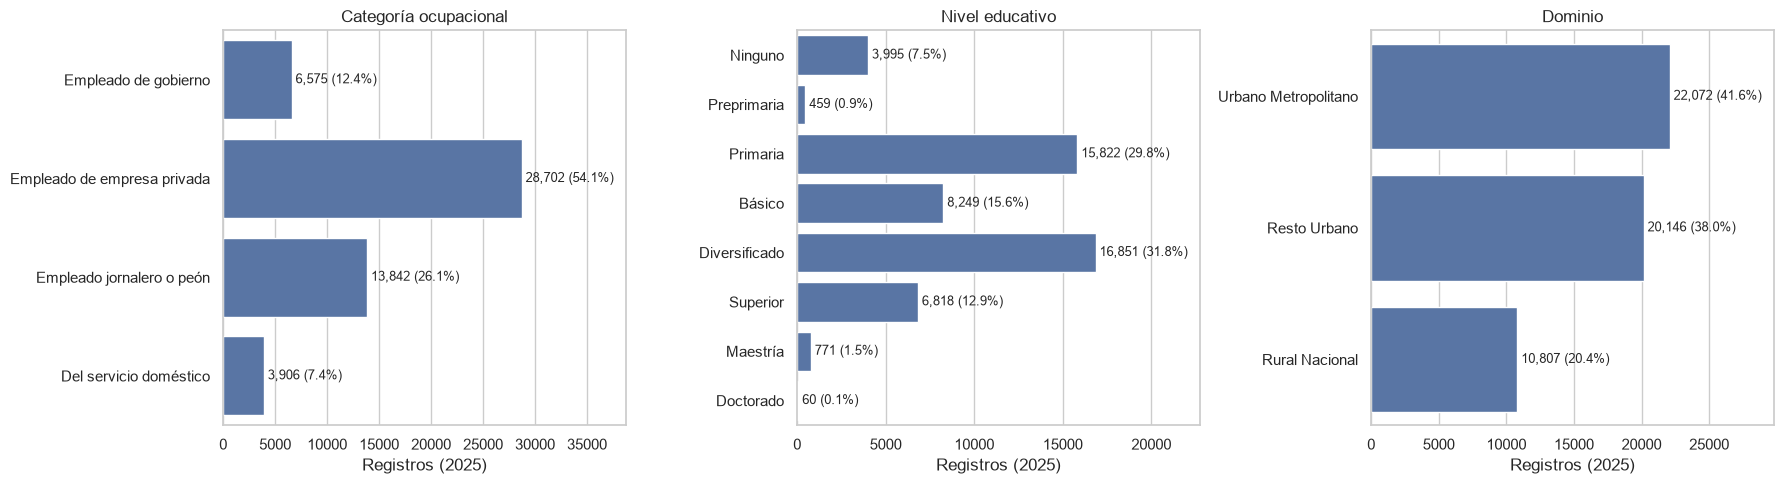

count    pct
categoria Empleado de gobierno          6575  12.40
          Empleado de empresa privada  28702  54.13
          Empleado jornalero o peón    13842  26.10
          Del servicio doméstico        3906   7.37
educacion Ninguno                       3995   7.53
          Preprimaria                    459   0.87
          Primaria                     15822  29.84
          Básico                        8249  15.56
          Diversificado                16851  31.78
          Superior                      6818  12.86
          Maestría                       771   1.45
          Doctorado                       60   0.11
dominio   Urbano Metropolitano         22072  41.63
          Resto Urbano                 20146  37.99
          Rural Nacional               10807  20.38

In [23]:
def conteo_cat(sdf, col, orden=None):
    t = sdf.groupBy(col, *( [orden] if orden else [] )).count().toPandas()
    t = t.sort_values(orden if orden else "count", ascending=bool(orden))
    t["pct"] = 100 * t["count"] / t["count"].sum()
    return t

cat_t = conteo_cat(df25, "categoria_ocupacional", "categoria_ocupacional_cod")
edu_t = conteo_cat(df25, "nivel_educativo", "nivel_educativo_cod")
dom_t = conteo_cat(df25, "dominio", "dominio_cod")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, t, col, titulo in [(axes[0], cat_t, "categoria_ocupacional", "Categoría ocupacional"),
                           (axes[1], edu_t, "nivel_educativo", "Nivel educativo"),
                           (axes[2], dom_t, "dominio", "Dominio")]:
    sns.barplot(data=t, y=col, x="count", ax=ax, color="#4C72B0", orient="h")
    for i, (n, p) in enumerate(zip(t["count"], t["pct"])):
        ax.text(n, i, f" {n:,} ({p:.1f}%)", va="center", fontsize=9)
    ax.set_title(titulo); ax.set_xlabel("Registros (2025)"); ax.set_ylabel("")
    ax.set_xlim(0, t["count"].max() * 1.35)
plt.tight_layout(); plt.show()
display(pd.concat({"categoria": cat_t.set_index("categoria_ocupacional")[["count", "pct"]],
                   "educacion": edu_t.set_index("nivel_educativo")[["count", "pct"]],
                   "dominio": dom_t.set_index("dominio")[["count", "pct"]]}).round(2))

Interpretación: 

En 2025, la mayoría de los registros son empleados de empresa privada (54.1%). Les siguen los jornaleros o peones (26.1%), los empleados de gobierno (12.4%) y el servicio doméstico (7.4%).

En educación, la mayoría tiene diversificado (31.8%) o primaria (29.8%). Preprimaria, maestría y doctorado tienen muy pocos registros (doctorado solo 60), así que sus resultados son poco confiables.

Por dominio, el 41.6% es urbano metropolitano, el 38.0% resto urbano y el 20.4% rural.

Estos porcentajes describen la muestra, no a todos los asalariados del país.

### Forma de la distribución del salario: simetría, media vs mediana

Muestra para graficar: 5,000 de 53,025 registros (las líneas usan estadísticas del total)


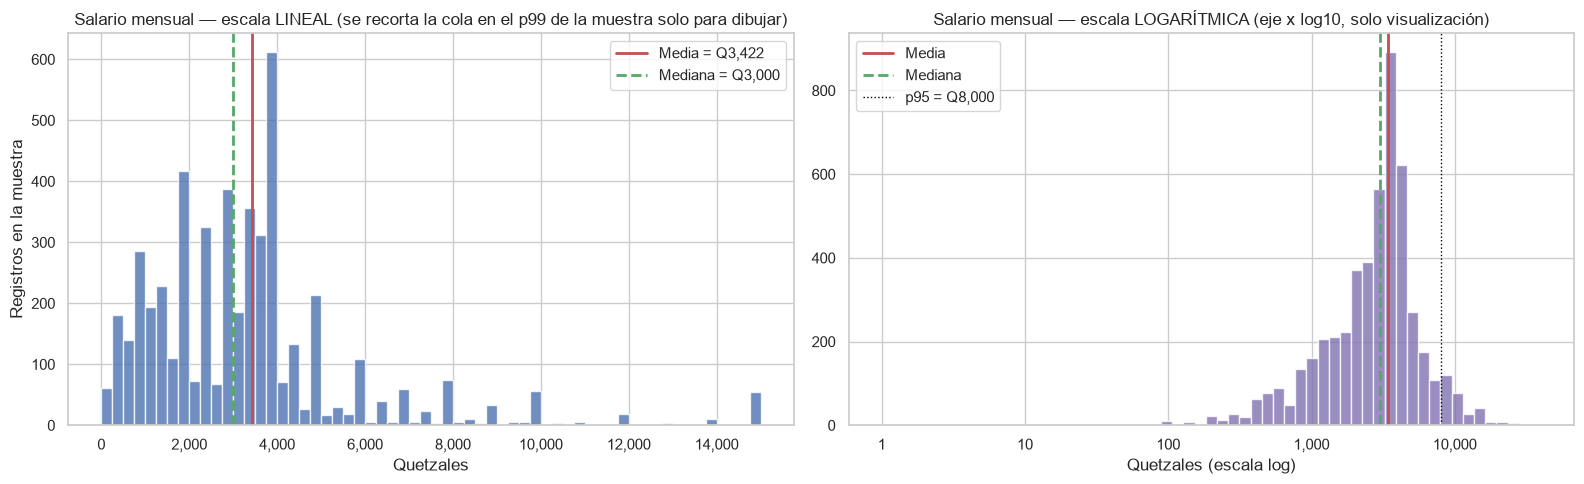

Media Q3,421.68 | Mediana Q3,000.00 | Diferencia Q421.68 (14.1% sobre la mediana) | Asimetría 6.00


In [24]:
n25 = df25.count()
muestra = (df25.sample(fraction=min(1.0, MAX_MUESTRA * 1.1 / n25), seed=SEED)
           .limit(MAX_MUESTRA).toPandas())
print(f"Muestra para graficar: {len(muestra):,} de {n25:,} registros (las líneas usan estadísticas del total)")

media_s, mediana_s = desc25.loc["salario_mensual", "media"], desc25.loc["salario_mensual", "mediana"]
p95_s = desc25.loc["salario_mensual", "p95"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
ax.hist(muestra.salario_mensual.clip(upper=muestra.salario_mensual.quantile(0.99)), bins=60, color="#4C72B0", alpha=.8)
ax.axvline(media_s, color="#C44E52", lw=2, label=f"Media = Q{media_s:,.0f}")
ax.axvline(mediana_s, color="#55A868", lw=2, ls="--", label=f"Mediana = Q{mediana_s:,.0f}")
ax.set_title("Salario mensual — escala LINEAL (se recorta la cola en el p99 de la muestra solo para dibujar)")
ax.set_xlabel("Quetzales"); ax.set_ylabel("Registros en la muestra"); ax.legend()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))

ax = axes[1]
bins = np.logspace(np.log10(muestra.salario_mensual.min()), np.log10(muestra.salario_mensual.max()), 60)
ax.hist(muestra.salario_mensual, bins=bins, color="#8172B2", alpha=.8)
ax.set_xscale("log")
ax.axvline(media_s, color="#C44E52", lw=2, label="Media")
ax.axvline(mediana_s, color="#55A868", lw=2, ls="--", label="Mediana")
ax.axvline(p95_s, color="black", lw=1, ls=":", label=f"p95 = Q{p95_s:,.0f}")
ax.set_title("Salario mensual — escala LOGARÍTMICA (eje x log10, solo visualización)")
ax.set_xlabel("Quetzales (escala log)"); ax.legend()
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

print(f"Media Q{media_s:,.2f} | Mediana Q{mediana_s:,.2f} | Diferencia Q{media_s - mediana_s:,.2f} "
      f"({100 * (media_s / mediana_s - 1):.1f}% sobre la mediana) | Asimetría {desc25.loc['salario_mensual', 'asimetria']:.2f}")

In [25]:
# Peso de la cola alta: participación de los salarios sobre p95 y p99 en el total de salarios (conjunto completo)
p99_s = df25.select(F.expr("percentile(salario_mensual, 0.99)")).first()[0]
cola = df25.agg(F.sum("salario_mensual").alias("total"),
                F.sum(F.when(F.col("salario_mensual") > p95_s, F.col("salario_mensual"))).alias("sobre_p95"),
                F.sum(F.when(F.col("salario_mensual") > p99_s, F.col("salario_mensual"))).alias("sobre_p99"),
                F.sum((F.col("salario_mensual") > 3 * desc25.loc["salario_mensual", "p95"]).cast("int")).alias("n_mayor_3xp95"),
                F.expr("percentile(salario_mensual, 0.5)").alias("mediana")).first()
media_sin_cola = df25.filter(F.col("salario_mensual") <= p99_s).agg(F.mean("salario_mensual")).first()[0]
pd.Series({"p99": p99_s,
           "% masa salarial del 5% superior": 100 * cola.sobre_p95 / cola.total,
           "% masa salarial del 1% superior": 100 * cola.sobre_p99 / cola.total,
           "media sin el 1% superior (solo referencia)": media_sin_cola,
           "registros con salario > 3×p95": cola.n_mayor_3xp95}).round(2)

p99                                           15000.00
% masa salarial del 5% superior                  16.45
% masa salarial del 1% superior                   4.78
media sin el 1% superior (solo referencia)     3281.44
registros con salario > 3×p95                   119.00
dtype: float64

Interpretación:

¿Simétrica o asimétrica?
El salario es muy asimétrico a la derecha. La mayoría gana entre Q1,800 y Q4,000, pero unos pocos ganan mucho más: el máximo es Q99,000. En la gráfica con escala logarítmica, la distribución se ve más equilibrada.

Media y mediana
La media es Q3,422 y la mediana es Q3,000. La media es mayor porque los salarios más altos la elevan. Por eso, la mediana describe mejor el salario típico.

Otros rasgos
Muchos salarios son cifras redondas, como Q3,000 o Q4,000, lo que es normal cuando las personas reportan su salario. También hay salarios muy bajos, de hasta Q1. Siguiendo las instrucciones, no se eliminó ningún valor extremo.

Efecto en los modelos
Los salarios muy altos harán que el RMSE sea mucho mayor que el MAE. Es probable que los modelos estimen por debajo de su valor real los salarios más altos.

### Salario mediano por nivel educativo y categoría ocupacional

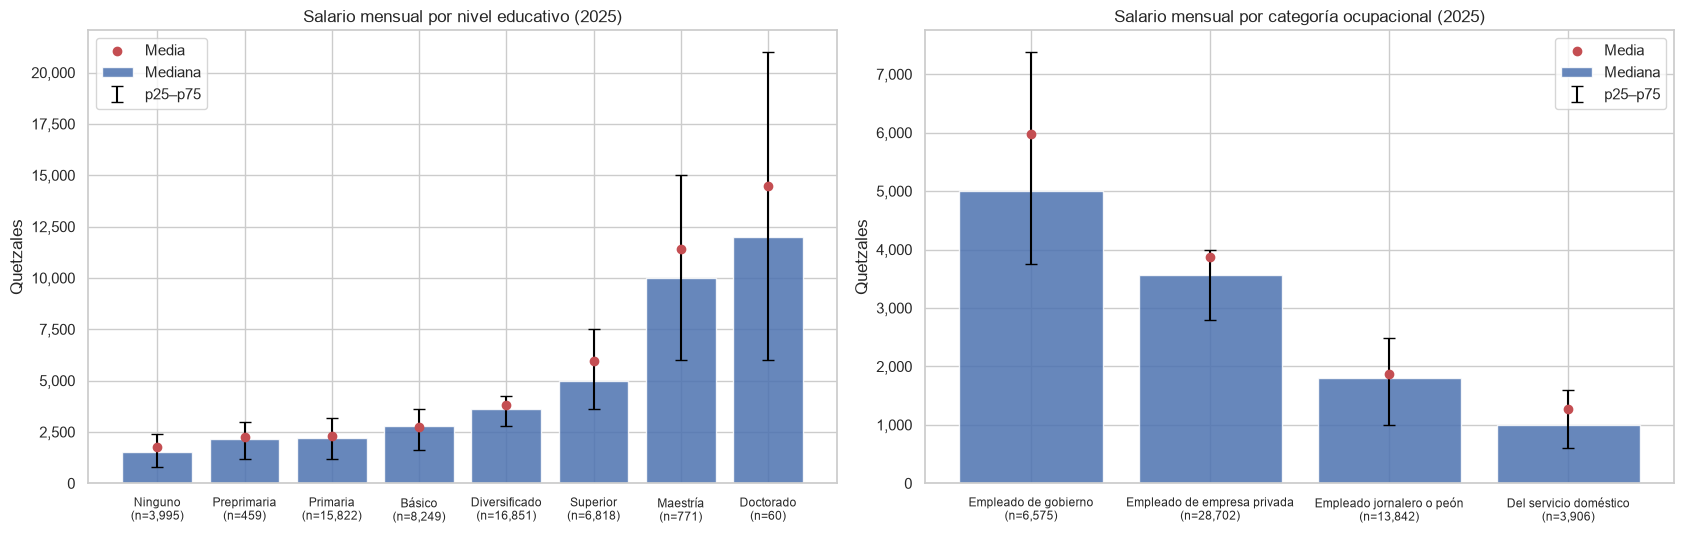

,nivel_educativo,nivel_educativo_cod,n,media,p25,mediana,p75
0,Ninguno,0,3995,1767.0,800.0,1500.0,2400.0
1,Preprimaria,1,459,2242.0,1200.0,2160.0,3000.0
2,Primaria,2,15822,2308.0,1200.0,2200.0,3200.0
3,Básico,3,8249,2730.0,1600.0,2800.0,3600.0
4,Diversificado,4,16851,3796.0,2800.0,3600.0,4250.0
5,Superior,5,6818,5965.0,3600.0,5000.0,7500.0
6,Maestría,6,771,11409.0,6000.0,10000.0,15000.0
7,Doctorado,7,60,14452.0,6000.0,12000.0,21000.0


,categoria_ocupacional,categoria_ocupacional_cod,n,media,p25,mediana,p75
0,Empleado de gobierno,1,6575,5972.0,3750.0,5000.0,7380.0
1,Empleado de empresa privada,2,28702,3875.0,2800.0,3568.0,4000.0
2,Empleado jornalero o peón,3,13842,1879.0,1000.0,1800.0,2490.0
3,Del servicio doméstico,4,3906,1266.0,600.0,1000.0,1600.0


In [26]:
def mediana_por(sdf, col, orden):
    t = (sdf.groupBy(col, orden)
         .agg(F.count(F.lit(1)).alias("n"),
              F.expr("percentile(salario_mensual, array(0.25, 0.5, 0.75))").alias("q"),
              F.mean("salario_mensual").alias("media"))
         .orderBy(orden).toPandas())
    t[["p25", "mediana", "p75"]] = pd.DataFrame(t.pop("q").tolist(), index=t.index)
    return t

med_edu = mediana_por(df25, "nivel_educativo", "nivel_educativo_cod")
med_cat = mediana_por(df25, "categoria_ocupacional", "categoria_ocupacional_cod")

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
for ax, t, col, titulo in [(axes[0], med_edu, "nivel_educativo", "por nivel educativo"),
                           (axes[1], med_cat, "categoria_ocupacional", "por categoría ocupacional")]:
    x = np.arange(len(t))
    ax.bar(x, t.mediana, color="#4C72B0", alpha=.85, label="Mediana")
    ax.errorbar(x, t.mediana, yerr=[t.mediana - t.p25, t.p75 - t.mediana], fmt="none", ecolor="black", capsize=4, label="p25–p75")
    ax.scatter(x, t.media, color="#C44E52", zorder=3, label="Media")
    ax.set_xticks(x); ax.set_xticklabels([f"{a}\n(n={n:,})" for a, n in zip(t[col], t.n)], rotation=0, fontsize=8.5)
    ax.set_title(f"Salario mensual {titulo} (2025)"); ax.set_ylabel("Quetzales")
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}")); ax.legend()
plt.tight_layout(); plt.show()
display(med_edu.round(0)); display(med_cat.round(0))

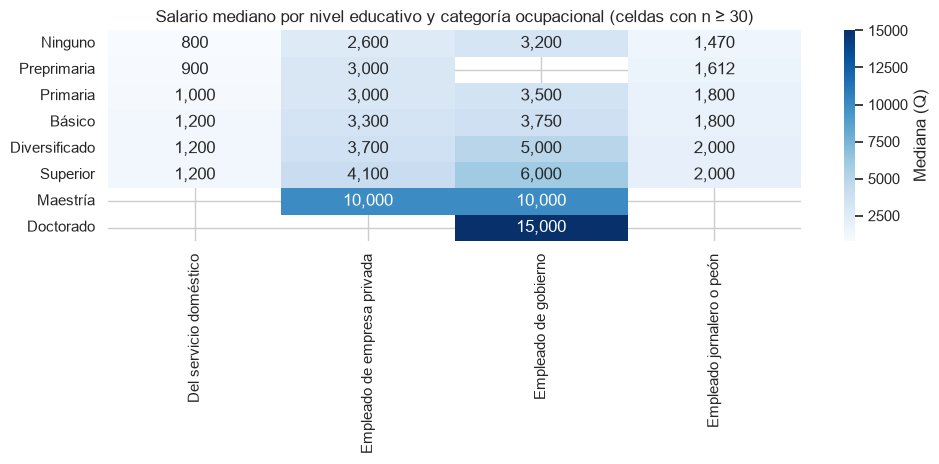

In [ ]:
cruce = (df25.groupBy("nivel_educativo_cod", "nivel_educativo", "categoria_ocupacional")
         .agg(F.expr("percentile(salario_mensual, 0.5)").alias("mediana"), F.count(F.lit(1)).alias("n"))
         .toPandas())
piv = cruce.pivot_table(index=["nivel_educativo_cod", "nivel_educativo"], columns="categoria_ocupacional", values="mediana")
piv_n = cruce.pivot_table(index=["nivel_educativo_cod", "nivel_educativo"], columns="categoria_ocupacional", values="n")
piv = piv.where(piv_n >= 30)  # se ocultan celdas con menos de 30 registros
piv.index = piv.index.get_level_values(1)
plt.figure(figsize=(10, 4.8))
sns.heatmap(piv, annot=True, fmt=",.0f", cmap="Blues", cbar_kws={"label": "Mediana (Q)"})
plt.title("Salario mediano por nivel educativo y categoría ocupacional (celdas con n ≥ 30)")
plt.ylabel(""); plt.xlabel(""); plt.tight_layout(); plt.show()

Interpretación:

Educación
El salario mediano sube con cada nivel educativo: Q1,500 sin estudios, Q2,200 con primaria, Q3,600 con diversificado, Q5,000 con estudios superiores y Q10,000 con maestría. El salto más grande está en los estudios universitarios. En los niveles más altos, los salarios también varían más entre personas.

Categoría ocupacional
Los empleados de gobierno tienen el salario mediano más alto (Q5,000). Les siguen los de empresa privada (Q3,568), los jornaleros (Q1,800) y el servicio doméstico (Q1,000).

Educación y categoría juntas
Aun con el mismo nivel educativo, gobierno sigue pagando más que la empresa privada, y esta más que el trabajo de jornalero o doméstico. En gobierno y empresa privada, más estudios se asocian con salarios mucho mayores. En cambio, para jornaleros y servicio doméstico el salario casi no cambia con la educación. Esto no demuestra que una cosa cause la otra; solo muestra que aparecen juntas.

### Tamaño de la muestra analítica y salario mediano por trimestre

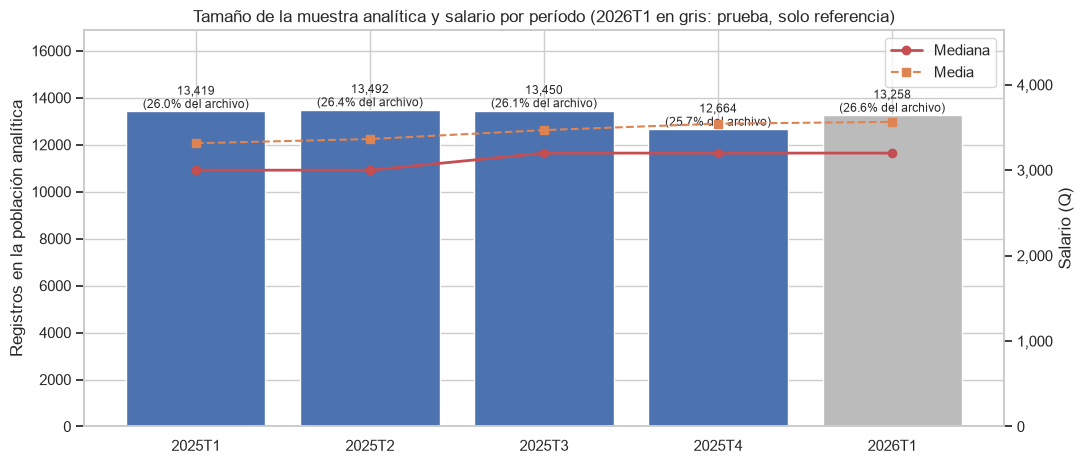

,periodo_archivo,n,mediana,media,antes_filtros,pct_retenido
0,2025T1,13419,3000.0,3315.63,51588,26.01
1,2025T2,13492,3000.0,3364.57,51167,26.37
2,2025T3,13450,3200.0,3469.07,51583,26.07
3,2025T4,12664,3200.0,3544.57,49338,25.67
4,2026T1,13258,3200.0,3565.80,49843,26.60


In [28]:
trim = (prep_todos.groupBy("periodo_archivo")
        .agg(F.count(F.lit(1)).alias("n"),
             F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
             F.mean("salario_mensual").alias("media"))
        .orderBy("periodo_archivo").toPandas())
trim = trim.merge(antes_despues[["antes_filtros"]], left_on="periodo_archivo", right_index=True)
trim["pct_retenido"] = 100 * trim.n / trim.antes_filtros

fig, ax1 = plt.subplots(figsize=(11, 4.8))
colores = ["#4C72B0"] * 4 + ["#BBBBBB"]
ax1.bar(trim.periodo_archivo, trim.n, color=colores)
for i, (n, p) in enumerate(zip(trim.n, trim.pct_retenido)):
    ax1.text(i, n, f"{n:,}\n({p:.1f}% del archivo)", ha="center", va="bottom", fontsize=8.5)
ax1.set_ylabel("Registros en la población analítica"); ax1.set_ylim(0, trim.n.max() * 1.25)
ax2 = ax1.twinx()
ax2.plot(trim.periodo_archivo, trim.mediana, "o-", color="#C44E52", lw=2, label="Mediana")
ax2.plot(trim.periodo_archivo, trim.media, "s--", color="#DD8452", lw=1.5, label="Media")
ax2.set_ylabel("Salario (Q)"); ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax2.set_ylim(0, trim.media.max() * 1.3); ax2.grid(False); ax2.legend(loc="upper right")
ax1.set_title("Tamaño de la muestra analítica y salario por período (2026T1 en gris: prueba, solo referencia)")
plt.tight_layout(); plt.show()
trim.round(2)

Interpretación:

Los tres primeros trimestres de 2025 tienen alrededor de 13,450 registros cada uno. En el cuarto baja a 12,664, porque ese archivo trae menos filas. En todos los trimestres se conserva cerca del 26% de los registros.

El salario mediano sube de Q3,000 en el primer y segundo trimestre a Q3,200 en el tercero y el cuarto. En el primer trimestre de 2026 se mantiene en Q3,200. Es un aumento pequeño y no está ajustado por inflación.

Por este aumento, un modelo entrenado con los tres primeros trimestres podría estimar salarios un poco más bajos que los reales en el cuarto trimestre y en 2026.

## Relaciones entre variables numéricas

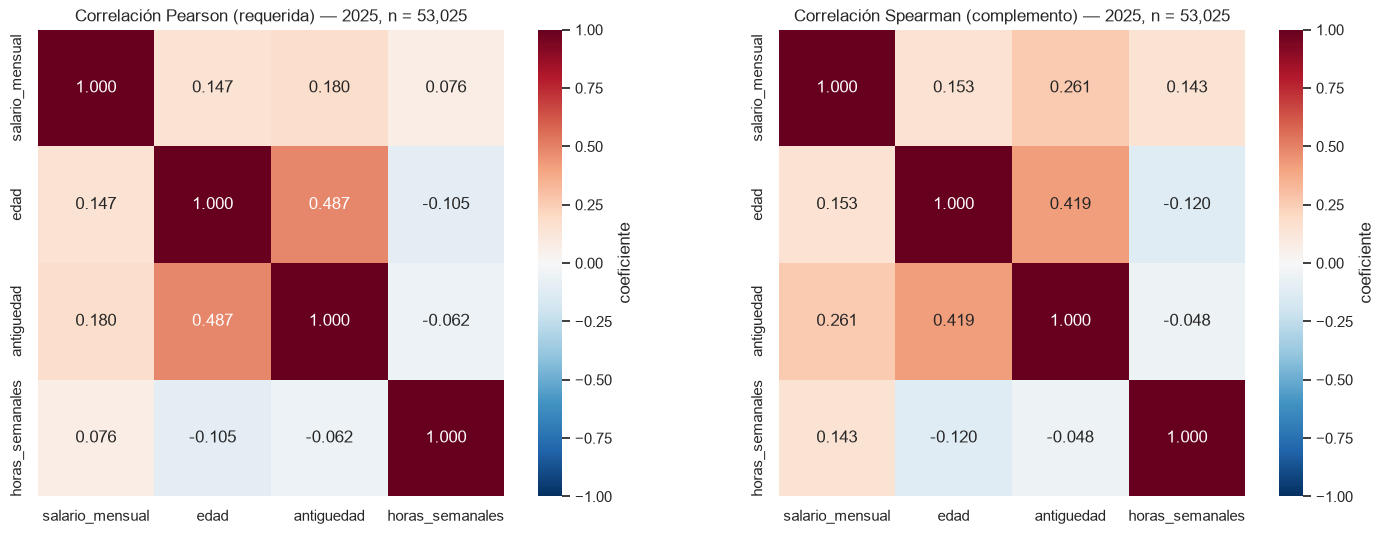

Matriz de Pearson:


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.0000,0.1472,0.1796,0.0757
edad,0.1472,1.0000,0.4867,-0.1054
antiguedad,0.1796,0.4867,1.0000,-0.0623
horas_semanales,0.0757,-0.1054,-0.0623,1.0000


In [29]:
vec = VectorAssembler(inputCols=NUMERICAS, outputCol="v").transform(df25).select("v")
pearson = pd.DataFrame(Correlation.corr(vec, "v", "pearson").first()[0].toArray(), index=NUMERICAS, columns=NUMERICAS)
spearman = pd.DataFrame(Correlation.corr(vec, "v", "spearman").first()[0].toArray(), index=NUMERICAS, columns=NUMERICAS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
for ax, m, t in [(axes[0], pearson, "Pearson (requerida)"), (axes[1], spearman, "Spearman (complemento)")]:
    sns.heatmap(m, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={"label": "coeficiente"})
    ax.set_title(f"Correlación {t} — 2025, n = {df25.count():,}")
plt.tight_layout(); plt.show()
print("Matriz de Pearson:"); display(pearson.round(4))

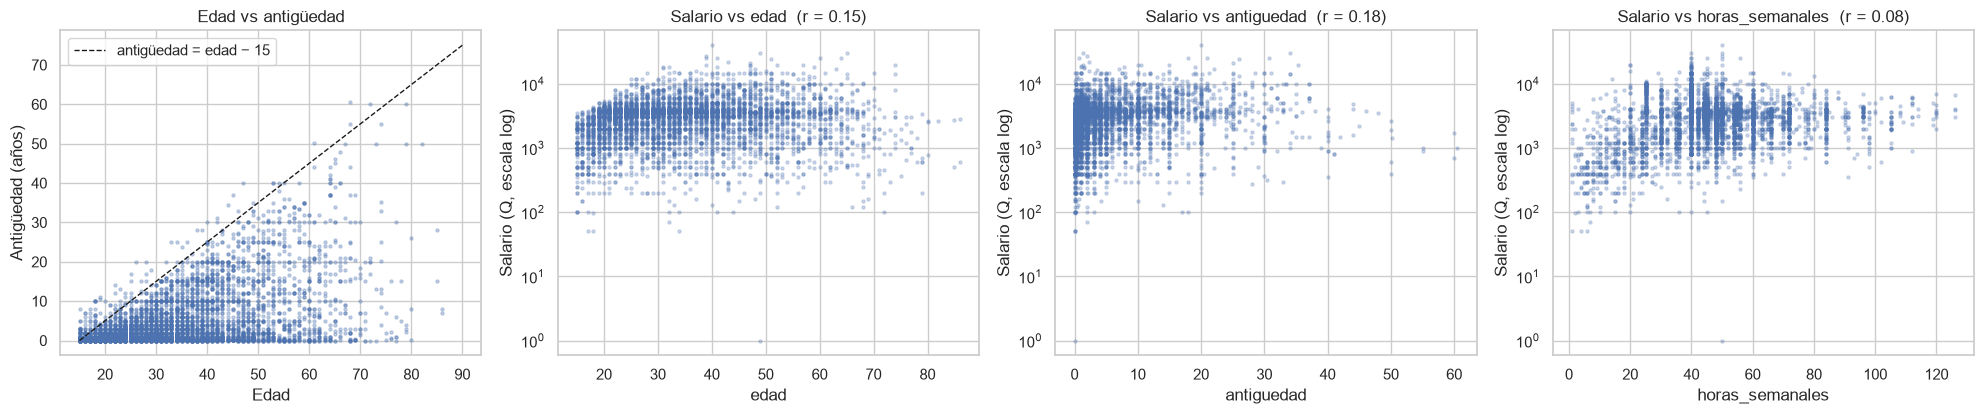

In [30]:
# Apoyo visual: edad vs antigüedad y salario vs cada variable (muestra ≤ 5,000; eje de salario en escala log)
fig, axes = plt.subplots(1, 4, figsize=(20, 4.3))
axes[0].scatter(muestra.edad, muestra.antiguedad, s=5, alpha=.3)
axes[0].plot([15, 90], [0, 75], "k--", lw=1, label="antigüedad = edad − 15")
axes[0].set_xlabel("Edad"); axes[0].set_ylabel("Antigüedad (años)"); axes[0].legend(); axes[0].set_title("Edad vs antigüedad")
for ax, c in zip(axes[1:], ["edad", "antiguedad", "horas_semanales"]):
    ax.scatter(muestra[c], muestra.salario_mensual, s=5, alpha=.25)
    ax.set_yscale("log"); ax.set_xlabel(c); ax.set_ylabel("Salario (Q, escala log)")
    ax.set_title(f"Salario vs {c}  (r = {pearson.loc['salario_mensual', c]:.2f})")
plt.tight_layout(); plt.show()

Interpretación:

¿Qué variables tienen mayor relación lineal con el salario?
Todas tienen una relación débil con el salario. La más alta es la antigüedad (0.18), seguida de la edad (0.15). Las horas trabajadas casi no se relacionan (0.08). Esto quiere decir que estas variables, por sí solas, explican poco del salario. La educación y la categoría ocupacional parecen influir más.

¿Existe relación entre edad y antigüedad?
Sí, es positiva y moderada (0.49). Tiene sentido, porque las personas mayores han tenido más tiempo para acumular años en un trabajo. No es más fuerte porque muchas personas mayores llevan poco tiempo en su empleo actual.

## Segmentación de perfiles con KMeans

In [31]:
def pipeline_kmeans(cols, k):
    return Pipeline(stages=[
        VectorAssembler(inputCols=cols, outputCol="x_raw"),
        StandardScaler(inputCol="x_raw", outputCol="x", withMean=True, withStd=True),
        KMeans(featuresCol="x", predictionCol="cluster", k=k, seed=SEED, maxIter=50, initMode="k-means||"),
    ])

evaluador = ClusteringEvaluator(featuresCol="x", predictionCol="cluster", metricName="silhouette",
                                distanceMeasure="squaredEuclidean")

CONJUNTOS = {
    "A: edad + antigüedad + horas": ["edad", "antiguedad", "horas_semanales"],
    "B: A + salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
}

resultados, modelos = [], {}
for nombre, cols in CONJUNTOS.items():
    for k in [2, 3, 4, 5]:
        m = pipeline_kmeans(cols, k).fit(df25)
        pred = m.transform(df25)
        tam = pred.groupBy("cluster").count().toPandas()["count"]
        resultados.append({"conjunto": nombre, "k": k, "silhouette": evaluador.evaluate(pred),
                           "wsse": m.stages[-1].summary.trainingCost,
                           "cluster_min_%": 100 * tam.min() / tam.sum(),
                           "tamaños": sorted(tam.tolist(), reverse=True)})
        modelos[(nombre, k)] = m
res_k = pd.DataFrame(resultados)
res_k.round(4)

,conjunto,k,silhouette,wsse,cluster_min_%,tamaños
0,A: edad + antigüedad + horas,2,0.5545,106717.3880,27.5417,"[38421, 14604]"
1,A: edad + antigüedad + horas,3,0.4718,83608.0362,19.0533,"[31073, 11849, 10103]"
2,A: edad + antigüedad + horas,4,0.4747,64437.0334,12.9109,"[24400, 12524, 9255, 6846]"
3,A: edad + antigüedad + horas,5,0.4421,62008.1946,5.1315,"[25447, 9814, 7636, 7407, 2721]"
4,B: A + salario,2,0.5146,157345.5575,27.0269,"[38694, 14331]"
5,B: A + salario,3,0.3371,133003.1555,16.7562,"[27367, 16773, 8885]"
6,B: A + salario,4,0.3753,113688.2467,4.4036,"[26534, 17029, 7127, 2335]"
7,B: A + salario,5,0.4137,94475.6732,3.9755,"[24238, 11474, 8885, 6320, 2108]"


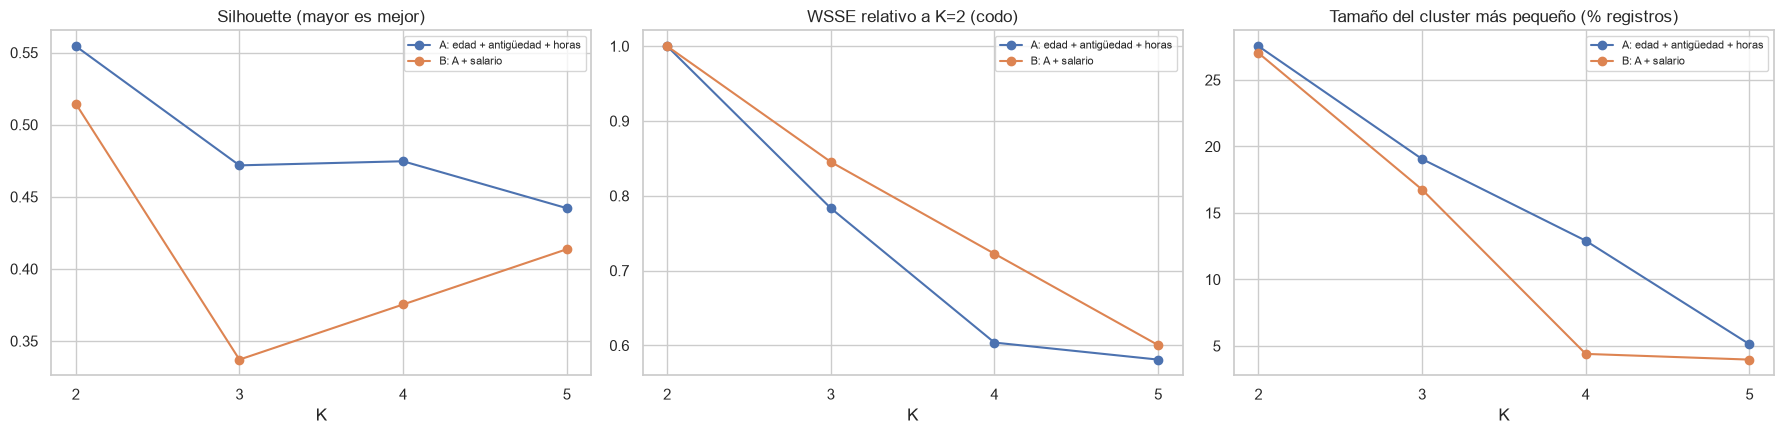

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for nombre, g in res_k.groupby("conjunto", sort=False):
    axes[0].plot(g.k, g.silhouette, "o-", label=nombre)
    axes[1].plot(g.k, g.wsse / g.wsse.iloc[0], "o-", label=nombre)
    axes[2].plot(g.k, g["cluster_min_%"], "o-", label=nombre)
axes[0].set_title("Silhouette (mayor es mejor)"); axes[1].set_title("WSSE relativo a K=2 (codo)")
axes[2].set_title("Tamaño del cluster más pequeño (% registros)")
for ax in axes:
    ax.set_xlabel("K"); ax.set_xticks([2, 3, 4, 5]); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
k_b = int(res_k[res_k.conjunto.str.startswith("B")].sort_values("silhouette", ascending=False).k.iloc[0])
pred_b = modelos[("B: A + salario", k_b)].transform(df25)
(pred_b.groupBy("cluster")
 .agg(F.count(F.lit(1)).alias("n"), F.round(F.mean("edad"), 1).alias("edad_media"),
      F.round(F.mean("antiguedad"), 1).alias("antig_media"), F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
      F.round(F.expr("percentile(salario_mensual, 0.5)"), 0).alias("salario_mediano"),
      F.round(F.min("salario_mensual"), 0).alias("salario_min"), F.round(F.max("salario_mensual"), 0).alias("salario_max"))
 .orderBy("cluster").toPandas())

,cluster,n,edad_media,antig_media,horas_media,salario_mediano,salario_min,salario_max
0,0,38694,29.4,2.4,47.9,3000.0,1.0,18000.0
1,1,14331,50.7,14.1,42.1,3750.0,40.0,99000.0


### Decisión: ¿incluir salario? ¿Qué K?

¿Vale la pena incluir el salario?
No. Al incluirlo, la silhouette baja para todos los valores de K. Además, como hay salarios extremadamente altos, se forman grupos muy pequeños de personas que ganan mucho, en lugar de perfiles laborales útiles. Por último, el salario es lo que queremos predecir en la segunda parte, así que conviene formar los grupos sin usarlo.

¿Qué K elegir?
Se tomaron en cuenta tres cosas: la silhouette, la curva de WSSE (método del codo) y que ningún grupo fuera demasiado pequeño.
- K = 2 tiene la mejor silhouette (0.555), pero solo separa a los jóvenes de los mayores.
- K = 4 tiene una silhouette un poco mayor que K = 3 (0.475 frente a 0.472) y es donde la curva de WSSE forma el codo. Su grupo más pequeño tiene casi el 13% de los registros.
- K = 5 tiene una silhouette más baja y genera un grupo muy pequeño.

Se eligió K = 4 sin salario. Los grupos tienen una estructura razonable, aunque no están totalmente separados entre sí.

In [ ]:
K_ELEGIDO = 4

In [ ]:
CONJUNTO_FINAL = "A: edad + antigüedad + horas"
K_FINAL = K_ELEGIDO if "K_ELEGIDO" in globals() else int(
    res_k[res_k.conjunto == CONJUNTO_FINAL].sort_values("silhouette", ascending=False).k.iloc[0])
modelo_km = modelos[(CONJUNTO_FINAL, K_FINAL)]
seg = modelo_km.transform(df25).drop("x_raw", "x").persist()
print(f"Segmentación final: {CONJUNTO_FINAL}, K = {K_FINAL}, "
      f"silhouette = {res_k[(res_k.conjunto == CONJUNTO_FINAL) & (res_k.k == K_FINAL)].silhouette.iloc[0]:.4f}")

scaler = modelo_km.stages[1]
centros_z = np.array(modelo_km.stages[-1].clusterCenters())
centros = centros_z * scaler.std.toArray() + scaler.mean.toArray()
cols_km = CONJUNTOS[CONJUNTO_FINAL]
centroides = pd.DataFrame(centros, columns=cols_km).round(2)
centroides_z = pd.DataFrame(centros_z, columns=cols_km).round(2)
display(centroides.add_suffix(" (centroide)").join(centroides_z.add_suffix(" (z)")))

Segmentación final: A: edad + antigüedad + horas, K = 4, silhouette = 0.4747


,edad (centroide),antiguedad (centroide),horas_semanales (centroide),edad (z),antiguedad (z),horas_semanales (z)
0,48.80,4.09,39.73,1.01,-0.19,-0.35
1,30.13,3.41,74.17,-0.37,-0.27,1.50
2,49.87,22.27,41.04,1.09,2.13,-0.28
3,26.00,2.44,40.59,-0.68,-0.40,-0.31


In [36]:
perfil = (seg.groupBy("cluster")
          .agg(F.count(F.lit(1)).alias("n"),
               F.mean("edad").alias("edad_media"), F.expr("percentile(edad, 0.5)").alias("edad_mediana"),
               F.mean("antiguedad").alias("antig_media"), F.expr("percentile(antiguedad, 0.5)").alias("antig_mediana"),
               F.mean("horas_semanales").alias("horas_media"), F.expr("percentile(horas_semanales, 0.5)").alias("horas_mediana"),
               F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
               F.mean("salario_mensual").alias("salario_media"),
               F.mean((F.col("nivel_educativo_cod") >= 4).cast("int")).alias("pct_diversificado_o_mas"),
               F.mean((F.col("dominio") == "Rural Nacional").cast("int")).alias("pct_rural"))
          .orderBy("cluster").toPandas())
perfil["pct_registros"] = 100 * perfil.n / perfil.n.sum()
for c in ["pct_diversificado_o_mas", "pct_rural"]:
    perfil[c] *= 100
perfil.round(1)

,cluster,n,edad_media,edad_mediana,antig_media,antig_mediana,horas_media,horas_mediana,salario_mediano,salario_media,pct_diversificado_o_mas,pct_rural,pct_registros
0,0,12524,48.8,47.0,4.1,3.0,39.7,42.0,3000.0,3537.8,37.6,18.1,23.6
1,1,9255,30.1,29.0,3.4,2.0,74.2,72.0,3000.0,3223.8,40.6,22.6,17.5
2,2,6846,49.9,48.0,22.3,20.0,41.0,40.0,3800.0,4683.3,49.8,16.7,12.9
3,3,24400,26.0,26.0,2.4,1.2,40.6,44.0,3000.0,3083.2,51.7,21.7,46.0


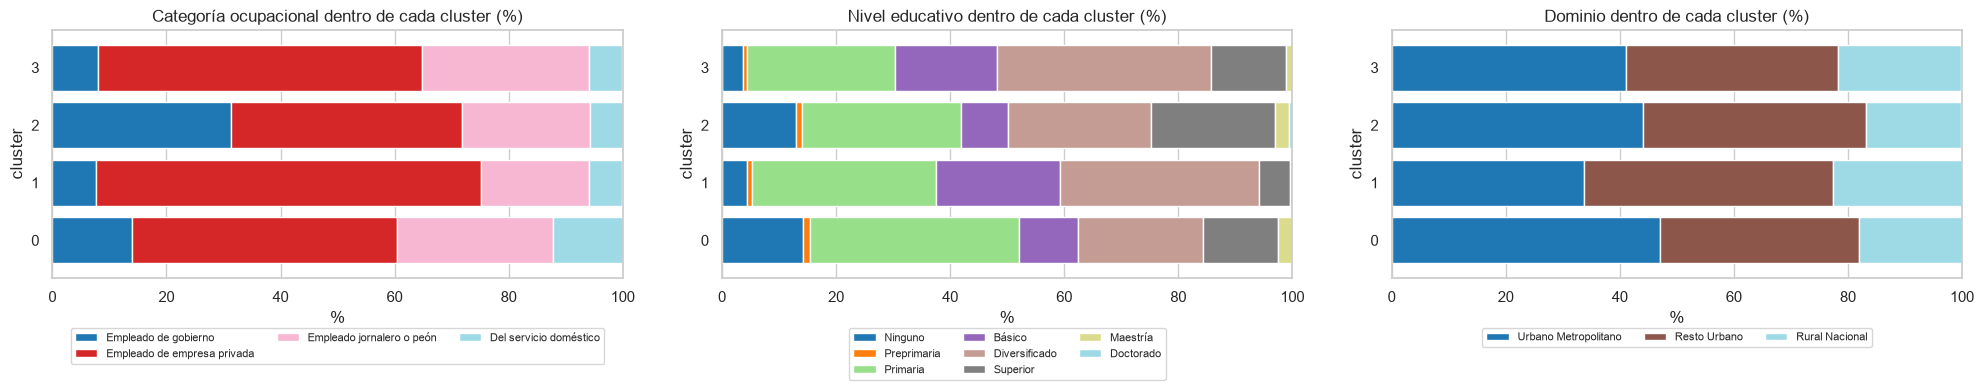

categoria_ocupacional,Empleado de gobierno,Empleado de empresa privada,Empleado jornalero o peón,Del servicio doméstico
cluster,,,,
0,14.0,46.5,27.3,12.2
1,7.7,67.4,19.0,5.8
2,31.4,40.4,22.4,5.9
3,8.0,56.8,29.2,5.9


nivel_educativo,Ninguno,Preprimaria,Primaria,Básico,Diversificado,Superior,Maestría,Doctorado
cluster,,,,,,,,
0,14.2,1.2,36.6,10.5,21.8,13.2,2.5,0.2
1,4.4,0.9,32.3,21.7,34.9,5.3,0.4,0.0
2,13.0,1.1,27.8,8.3,25.1,21.7,2.4,0.5
3,3.7,0.6,26.0,17.9,37.6,13.1,1.0,0.0


dominio,Urbano Metropolitano,Resto Urbano,Rural Nacional
cluster,,,
0,47.1,34.9,18.1
1,33.8,43.6,22.6
2,44.0,39.2,16.7
3,41.1,37.1,21.7


In [37]:
def composicion(col, orden):
    t = seg.groupBy("cluster", col, orden).count().toPandas()
    t["pct"] = 100 * t["count"] / t.groupby("cluster")["count"].transform("sum")
    return t.sort_values(orden).pivot(index="cluster", columns=col, values="pct")[
        t.sort_values(orden)[col].unique()].round(1)

comp_cat = composicion("categoria_ocupacional", "categoria_ocupacional_cod")
comp_edu = composicion("nivel_educativo", "nivel_educativo_cod")
comp_dom = composicion("dominio", "dominio_cod")

fig, axes = plt.subplots(1, 3, figsize=(20, 4.2))
for ax, t, titulo in [(axes[0], comp_cat, "Categoría ocupacional"), (axes[1], comp_edu, "Nivel educativo"),
                      (axes[2], comp_dom, "Dominio")]:
    t.plot(kind="barh", stacked=True, ax=ax, colormap="tab20", width=.8, legend=False)
    ax.set_title(f"{titulo} dentro de cada cluster (%)"); ax.set_xlabel("%"); ax.set_xlim(0, 100)
    ax.legend(loc="upper center", bbox_to_anchor=(.5, -.18), ncol=3, fontsize=8)
plt.tight_layout(); plt.show()
display(comp_cat); display(comp_edu); display(comp_dom)

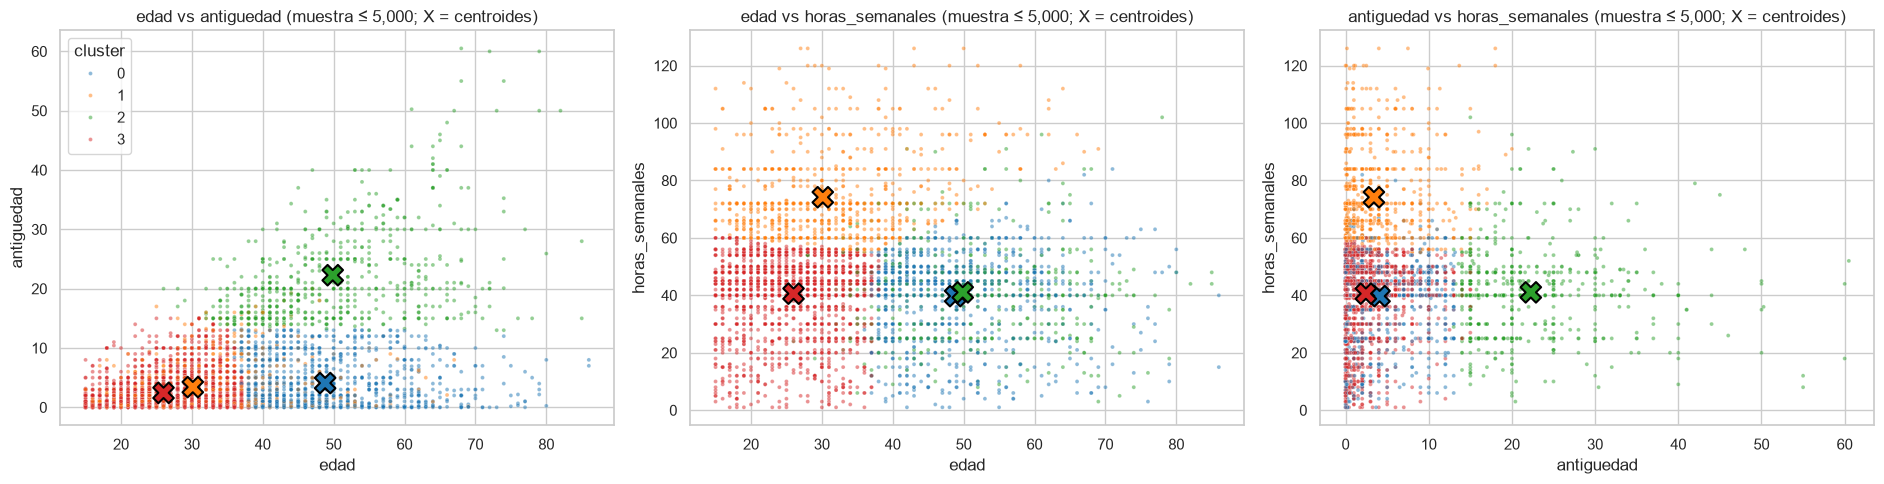

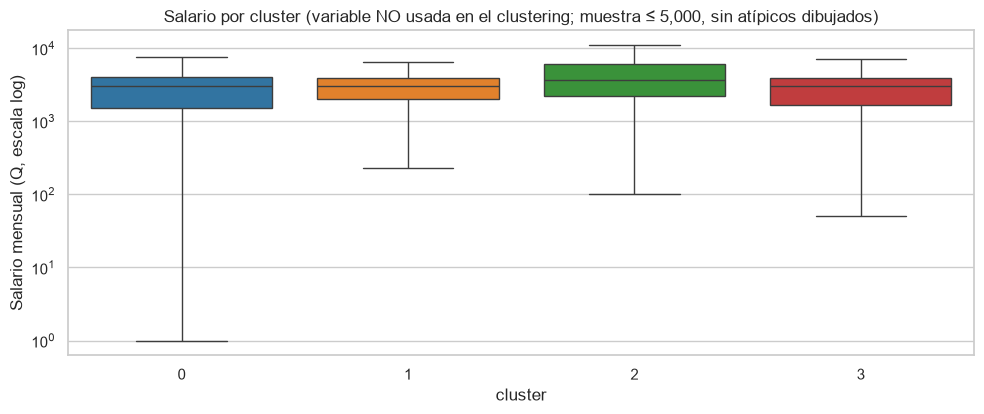

In [38]:
m_seg = (seg.sample(fraction=min(1.0, MAX_MUESTRA * 1.1 / n25), seed=SEED).limit(MAX_MUESTRA)
         .select("cluster", "edad", "antiguedad", "horas_semanales", "salario_mensual").toPandas())
pal = sns.color_palette("tab10", K_FINAL)
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
pares = [("edad", "antiguedad"), ("edad", "horas_semanales"), ("antiguedad", "horas_semanales")]
for ax, (a, b) in zip(axes, pares):
    sns.scatterplot(data=m_seg, x=a, y=b, hue="cluster", palette=pal, s=8, alpha=.5, ax=ax, legend=(ax is axes[0]))
    ax.scatter(centroides[a], centroides[b], marker="X", s=220, c=pal, edgecolor="black", linewidth=1.5)
    ax.set_title(f"{a} vs {b} (muestra ≤ 5,000; X = centroides)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(10, 4.3))
sns.boxplot(data=m_seg, x="cluster", y="salario_mensual", hue="cluster", palette=pal, legend=False, ax=ax, showfliers=False)
ax.set_yscale("log"); ax.set_ylabel("Salario mensual (Q, escala log)")
ax.set_title("Salario por cluster (variable NO usada en el clustering; muestra ≤ 5,000, sin atípicos dibujados)")
plt.tight_layout(); plt.show()

### Guardado de la segmentación

In [39]:
modelo_km.write().overwrite().save("modelos/kmeans_perfiles")
seg.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "cluster").write.mode("overwrite").parquet(str(PQ / "segmentacion_2025"))
print("Modelo: modelos/kmeans_perfiles | Etiquetas:", PQ / "segmentacion_2025")

Modelo: modelos/kmeans_perfiles | Etiquetas: data/parquet/segmentacion_2025
